# Koopman operator learning, a toy case: Duffing oscillator

## Instructions

- You must submit **two files**:
  1. **This notebook**, fully completed and including the output of the cells.  
     The notebook will **not** be executed during grading; it will be **read**.  
     Make sure it is clear, well presented, and easy to follow, since presentation will be taken into account in the grading.
  2. **A `.npy` file** containing some of the results of your experiments.  
     You can generate this file from the `results` dictionary using the relevant cells (see below + end of notebook).  
     This dictionary will be progressively completed with the relevant results during the practical session. Make sure it contains all the required results before generating the file.

- Make sure to **follow all naming conventions exactly** when submitting both files.

In [1]:
import numpy as np

results = {}
results["id"] = np.random.randint(0, 100000)

In [2]:
name = "Adonis_JAMAL_Jean-Vincent_MARTINI"
file_path = f"results_{name}.npy"
np.save(file_path, results)

In [3]:
# Run this cell to check that your .npy file has been correctly saved and contains the expected results.
loaded_results = np.load(file_path, allow_pickle=True).item()
print(loaded_results.keys())

dict_keys(['id'])



The aim of this notebook is to describe the dynamics of a non-linear dynamical system by means of the Koopman theory.

## Introduction

We consider a quantity $x \in \mathbb{R}^n$ (a vector) which evolves with time, following a dynamical system. Think for example of the joint location of the planets in our solar system, which follows the law of gravitation.

Formally, given an initial state $x(t=0) \in \mathbb{R}^n$ at time $t=0$, the time evolution of $x$ is governed by the following dynamical system:
$$
\dot{x}(t) = f(x(t)) \quad \text(1)
$$

where $\dot{x}(t) := \frac{dx(t)}{dt}$ is the temporal derivative, and $f:\mathbb{R}^n \rightarrow \mathbb{R}^n$ is a given map describing the dynamics.

For a given $f$, it is not always possible to solve the differential equation (1) analytically. For this reason, instead, numerical schemes are usually employed, to integrate in time $t$ the equation (1), so as to propagate the initial condition $x(0)$ up to a desired time $T$; think of $x(T) = x(0) + \int_{t=0}^{T} f(x(t)) dt$. The discretization in time of eq (1) or of the integral introduces numerical approximations, and yields estimates of $x(T)$ of various quality depending on the discretization scheme.

In the field of numerical simulations, discretization schemes have been studied for a long time, and numerical solvers already exist to provide good estimates of integrals (far better than with the naive discretization $x_{k+\delta} = x_k + \delta\,f(x_k)$ for a discrete time increment $\delta$, which induces a $O(\delta^2)$ error at each time step).

The goal of this practical session is to make use of such numerical solvers to improve the learning of dynamical systems with neural networks.

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm

from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

# arrange the dataset
from sklearn.model_selection import train_test_split

## Duffing oscillator

As a toy example, we consider the Duffing oscillator, where the state $x = (x_1, x_2) \in \mathbb{R}^2$ follows the dynamical system described by the following ODEs:

$$
\dot{x}_1 = x_2\\
\dot{x}_2 = x_1 - x_1^3
$$

To integrate in time the ODEs, a 4th order Runge-Kutta scheme can be used. 


In [5]:
def duffing(array_x: np.ndarray) -> np.ndarray:
    array_dx = np.zeros(array_x.shape)
    array_dx[0] = array_x[1]
    array_dx[1] = array_x[0] - array_x[0] ** 3
    return array_dx

In [6]:
t_max = 500  # Time-horizon integration
n_iter = 5000  # Number of time steps integration
n_initial_conditions = 60  # Number of initial conditions

dim_system = 2

# Generate initial conditions
matrix_x0 = (
    np.random.rand(n_initial_conditions, dim_system) - 0.5
) * 4  # Uniform distribution in [-2, 2]
array_t = np.linspace(0, t_max, n_iter)
array3d_xt = np.zeros((matrix_x0.shape[0], matrix_x0.shape[1], n_iter))

for i in tqdm(range(matrix_x0.shape[0])):
    # Lambda function is used as solve_ivp requires a function of the form f(t, x)
    ode_result = solve_ivp(
        lambda _t, array_x: duffing(array_x),
        [0, t_max],
        matrix_x0[i],
        method="RK45",
        t_eval=array_t,
    )

    array3d_xt[i, :] = ode_result.y

100%|██████████| 60/60 [00:01<00:00, 46.37it/s]


The following plot shows trajectories for different initial conditions:

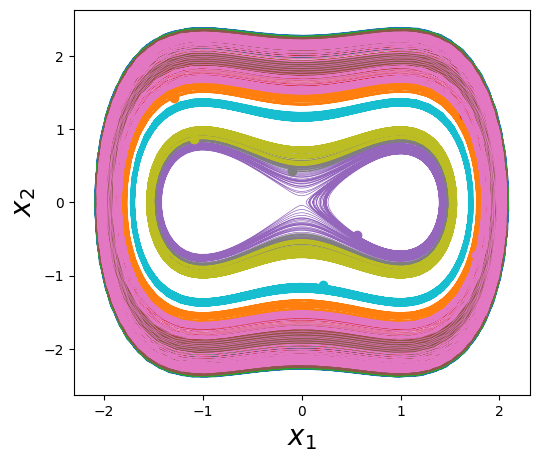

In [7]:
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(131)
cm = plt.get_cmap("tab10")
print(cm)
for i in range(10):
    ax.plot(array3d_xt[i, 0, :], array3d_xt[i, 1, :], lw=0.5, color=cm(i))
    ax.plot(
        array3d_xt[i, 0, 0], array3d_xt[i, 1, 0], "o", lw=1.5, color=cm(i)
    )  # initial condition
ax.set_xlabel("$x_1$", fontsize=20)
ax.set_ylabel("$x_2$", fontsize=20)
plt.show()

## The Koopman operator
### Discontinuous in time case
Given the discrete non-linear dynamical system

$$
x_{k+1} = F(x_k)
$$

where $F$ might be the $\delta$-discretised flow map of the continuous dynamical system in eq (1) given by

$$
x_{k+1} = F(x_k) := x_k + \int_{k}^{k + \delta} f(x(s))ds 
$$

and $X = (x_k)_{k = 0}^N$ the discrete time series of the system state.


The _Koopman_ theory states that there exists an infinite-dimensional linear operator $\mathcal{K}$ that advances in time all observable functions $(g_i)_{i = 1}^m$ given by $g_i: \mathbb{R}^n \rightarrow \mathbb{R}$

$$
\mathcal{K} g_i(x) = g_i \circ F(x)
$$

This way, the non-linear dynamics of $x$, described by $F$, can be turned into a **linear** dynamical system, described by $\mathcal{K}$, acting on another representation space, formed by the observable quantities $g_i(x)$.

Indeed, let $g_i$ be an observable function and denoting ${g_i}_k := g_i(x_k)$, using the previous equation, the time evolution of the observables is given by

$$
{g_i}_{k+1} = g_i(x_{k+1}) = g_i(F(x_k)) = g_i \circ F(x_k) = \mathcal{K} g_i(x_k) = \mathcal{K} {g_i}_k
$$

then, the linearised dynamics of the observables is given by the following equation

$$
{g_i}_{k+1} = \mathcal{K} {g_i}_k
$$


It is then sufficient to find a function $g: \mathbb{R}^n \rightarrow \mathbb{R}^m$ with $m \gg n$ that embeds the state $x$ into a "larger enough" dimensional space $m$ such that the linear operator $\mathcal{K}$ can be inferred by a matrix $\mathbf{K} \in \mathbb{R}^{m \times m}$.

To project back the dynamics from the Koopman space ($\mathbb{R}^m$, where $g(x)$ lives) to the phase space ($\mathbb{R}^n$, where $x$ lives), a supplementary function $\varphi: \mathbb{R}^m \rightarrow \mathbb{R}^n$ is needed. Going from $x$ to the Koopman space and back yields $\varphi \text{ o  } g = $ Id.

Under this condition, the functions $g$, $\varphi$ and $\mathbf{K}$ can be parametrized $g_{\theta}$, $\varphi_{\rho}$ and $\mathbf{K}_{\phi}$, and the parameters $\theta$, $\rho$ and $\phi$ can be learned minimizing suitable loss functions. 

For this purpose, given a time series $X = \{x_k | k = 1 \ldots N \}$, the following conditions hold:


1.   Reconstruction error
     $$
     \Vert \varphi_\rho (g_\theta(x_k)) - x_k  \Vert = 0
     $$
2.   Prediction error in Koopman space
     $$
     \Vert \mathbf{K_{\phi}} g_{\theta} ( x_k ) - g_{\theta} (x_{k+1})  \Vert = 0
     $$
3.   Prediction error in the phase space
     $$
     \Vert \varphi_{\rho} \left( \mathbf{K_{\phi}} g_{\theta} ( x_k )\right) - x_{k+1} \Vert = 0
     $$

The last three errors can be used as loss functions to train three different neural networks. These different neural networks compose our architecture that can be summarized as in the following sketch:



![architecture](./architecture.png) 

In [8]:
# Flatten the trajectories w.r.t. initial conditions
# and only keep data in the form of (dim_system, n_iter * n_initial_conditions)
matrix_x_data = array3d_xt[:, :, :-1].swapaxes(0, 1).reshape(2, -1).T
matrix_x_next_data = array3d_xt[:, :, 1:].swapaxes(0, 1).reshape(2, -1).T

(
    matrix_x_data_train,
    matrix_x_data_test,
    matrix_x_next_data_train,
    matrix_x_next_data_test,
) = train_test_split(matrix_x_data, matrix_x_next_data, test_size=0.2)

# Cast type to float32
matrix_x_data_train = matrix_x_data_train.astype(np.float32)
matrix_x_data_test = matrix_x_data_test.astype(np.float32)
matrix_x_next_data_train = matrix_x_next_data_train.astype(np.float32)
matrix_x_next_data_test = matrix_x_next_data_test.astype(np.float32)

print(
    matrix_x_data_train.shape,
    matrix_x_data_test.shape,
    matrix_x_next_data_train.shape,
    matrix_x_next_data_test.shape,
)

(239952, 2) (59988, 2) (239952, 2) (59988, 2)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [10]:
torch.set_default_dtype(torch.float32)
# torch.set_default_tensor_type('torch.DoubleTensor')

batch_size = 2000  # data per batch

tensor2d_x_data_train = torch.from_numpy(matrix_x_data_train).to(device)
tensor2d_x_next_data_train = torch.from_numpy(matrix_x_next_data_train).to(device)
tensor2d_x_data_test = torch.from_numpy(matrix_x_data_test).to(device)
tensor2d_x_next_data_test = torch.from_numpy(matrix_x_next_data_test).to(device)

torch_dataset_train = TensorDataset(tensor2d_x_data_train, tensor2d_x_next_data_train)

torch_dataset_test = TensorDataset(tensor2d_x_data_test, tensor2d_x_next_data_test)

train_dataloader = DataLoader(torch_dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(torch_dataset_test, batch_size=batch_size, shuffle=True)

# create the models
feature_dim = 2  # dimension of the Duffing oscillator
hidden_layer = 5  # number of hidden layers in g (ENCODER) and \varphi (DECODER)
output_dim = 30  # dimension in Koopman space

In [11]:
class Encoder(nn.Module):
    def __init__(self, list_layer_dim: list):
        super().__init__()
        self.list_layer_dim = list_layer_dim
        self.list_FC = nn.ModuleList()
        for i in range(len(self.list_layer_dim) - 1):
            input_dim = self.list_layer_dim[i]
            output_dim = self.list_layer_dim[i + 1]
            self.list_FC.append(nn.Linear(input_dim, output_dim))

    def forward(self, tensor2d_x):
        for i in range(len(self.list_layer_dim) - 2):
            tensor2d_x = F.elu(self.list_FC[i](tensor2d_x))
        return self.list_FC[-1](tensor2d_x)


In [12]:
class Decoder(nn.Module):
    def __init__(self, list_layer_dim: list):
        super().__init__()
        self.list_layer_dim = list_layer_dim
        self.list_FC = nn.ModuleList()
        for i in range(len(self.list_layer_dim) - 1, 0, -1):
            input_dim = self.list_layer_dim[i]
            output_dim = self.list_layer_dim[i - 1]
            self.list_FC.append(nn.Linear(input_dim, output_dim))

    def forward(self, tensor2d_x: torch.Tensor):
        for i in range(len(self.list_layer_dim) - 2):
            tensor2d_x = F.elu(self.list_FC[i](tensor2d_x))
        return self.list_FC[-1](tensor2d_x)

In [13]:
class Autoencoder(nn.Module):
    def __init__(self, feature_dim: int, hidden_layer: int, output_dim: int):
        super().__init__()
        list_layer_dim = [
            output_dim
            if i == hidden_layer
            else feature_dim + i * (output_dim - feature_dim) // hidden_layer
            for i in range(hidden_layer + 1)
        ]
        self.encoder = Encoder(list_layer_dim)
        self.decoder = Decoder(list_layer_dim)

    def forward(self, tensor2d_x: torch.Tensor):
        tensor2d_x = self.Encoder(tensor2d_x)
        return self.Decoder(tensor2d_x)

The Koopman operator $\mathbf{K}$ (which is linear, and thus a matrix) must have a [spectral radius](https://en.wikipedia.org/wiki/Spectral_radius) $\rho(\mathbf{K})\le 1$. Such condition will provide a stable -or at least a marginally stable- Koopman operator. To fulfill this requirement, we might leverage on the Perron-Frobenius theorem. 

The Perron-Frobenius th. states: if $\mathbf{K}$ is a $m \times m$ positive matrix i.e. $k_{ij} > 0$ for $1 \le i,j \le m$, then the following inequality holds:

$$
\min_i \sum_j k_{ij} \le \rho(\mathbf{K}) \le \max_i \sum_j k_{ij}
$$


**Question 1.** : Complete the `KoopmanModule` class to enforce $\rho(\mathbf{K})\le 1$, using the Perron-Frobenius theorem. Check that the initialization fulfills this property.

In [14]:
class KoopmanOperator(nn.Module):
    def __init__(self, koopman_operator_dim: int):
        super().__init__()
        self.koopman_operator_dim = koopman_operator_dim
        # TODO: Complete the KoopmanOperator class

        self.weight = self.create_matrix_weight()

    def create_matrix_weight(self):
        # Initialise the weight as a random matrix
        matrix = torch.randn(self.koopman_operator_dim, self.koopman_operator_dim)

        # Enforce the spectral radius to be less than 1 using Perron-Frobenius theorem
        matrix = torch.abs(matrix)
        row_sums = matrix.sum(dim=1, keepdim=True)
        max_row_sums = torch.max(row_sums)

        if max_row_sums > 1:
            matrix = matrix / max_row_sums

        return nn.Parameter(matrix)

    def forward(self, tensor2d_x: torch.Tensor):
        # First dimension of tensor2d_x is the batch size
        if tensor2d_x.shape[1] != self.koopman_operator_dim:
            sys.exit(
                f"Wrong Input Features. Please use tensor"
                f" with {self.koopman_operator_dim} Input Features"
            )

        return torch.matmul(tensor2d_x, self.weight.T)


dim_observable = 10
koopman_operator = KoopmanOperator(dim_observable).to(device)
results["koopman_operator_weight"] = koopman_operator.weight.cpu().detach().numpy()
results["koopman_operator_forward"] = (
    koopman_operator(torch.ones(1, dim_observable).to(device)).cpu().detach().numpy()
)

Spectral radius: 0.6637725830078125


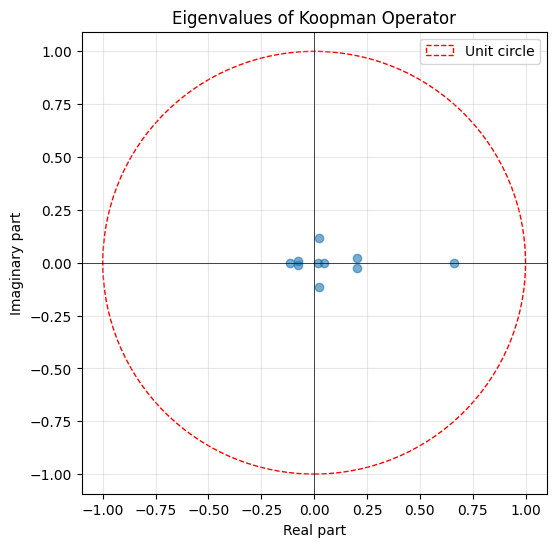

In [15]:
# Check the spectrum initialisation
koopman_matrix = koopman_operator.weight.cpu().detach().numpy()
eigenvalues = np.linalg.eig(koopman_matrix)[0]
spectral_radius = np.max(np.abs(eigenvalues))
print(f"Spectral radius: {spectral_radius.item()}")

# Plot eigenvalues in the complex plane
plt.figure(figsize=(6, 6))
plt.scatter(eigenvalues.real, eigenvalues.imag, alpha=0.6)
circle = plt.Circle(
    (0, 0), 1, color="r", fill=False, linestyle="--", label="Unit circle"
)
plt.gca().add_patch(circle)
plt.axhline(y=0, color="k", linestyle="-", linewidth=0.5)
plt.axvline(x=0, color="k", linestyle="-", linewidth=0.5)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Eigenvalues of Koopman Operator")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
autoencoder = Autoencoder(feature_dim, hidden_layer, output_dim).to(device)
koopman_operator = KoopmanOperator(output_dim).to(device)
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=2, out_features=7, bias=True)
      (1): Linear(in_features=7, out_features=13, bias=True)
      (2): Linear(in_features=13, out_features=18, bias=True)
      (3): Linear(in_features=18, out_features=24, bias=True)
      (4): Linear(in_features=24, out_features=30, bias=True)
    )
  )
  (decoder): Decoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=30, out_features=24, bias=True)
      (1): Linear(in_features=24, out_features=18, bias=True)
      (2): Linear(in_features=18, out_features=13, bias=True)
      (3): Linear(in_features=13, out_features=7, bias=True)
      (4): Linear(in_features=7, out_features=2, bias=True)
    )
  )
)


In [17]:
learning_rate_autoencoder = 0.0001
learning_rate_koopman = 0.00001

optimiser_autoencoder = torch.optim.Adam(
    autoencoder.parameters(), lr=learning_rate_autoencoder
)

optimiser_koopman = torch.optim.Adam(
    koopman_operator.parameters(), lr=learning_rate_koopman
)

**Question 2.** : Define a function to compute the loss to be minimized. It should at least include the 3 terms listed above:
- Reconstruction error
- Prediction error in the Koopman space
- Prediction error in the phase space

Because the different objectives outlined by these losses may compete, the training can be difficult. You may try different variations on these losses and comment your findings. In order to improve the training process, one can for instance:
- Add a multiplicative factor in front of each loss component, to balance their importance; how the scales of different losses are related?
- We can refine the loss acting upon the latent space, by using a variational autoencoder approach. This is similar to the Gaussian likelihood used in the first practical (TD1). We want the prediction in the latent space (i.e. the Koopman space) to be a normal distribution $\mathcal{N}(0, 1)$ . Add a corresponding loss for the latent space. Difference to 0 mean and 1 standard deviation must be thus included in the loss;
- Freeze the gradients of one part of the network, for instance the encoder, for one specific objective, using the [`requires_grad`](https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad_.html) property. For instance:
```python
criterion = nn.MSELoss()
...
# Compute one part loss_l of the total loss
# First deactivate gradient computation for irrelevant parts of the architecture
for p in autoencoder.encoder.parameters():
    p.requires_grad = False
loss_l = criterion(pred, target)
# Restore the gradient computation
for p in autoencoder.encoder.parameters():
    p.requires_grad = True
...
total_loss = loss_1 + ... + loss_l + ...
```

In [18]:
def loss_koopman(
    tensor2d_x: torch.Tensor,
    tensor2d_x_next: torch.Tensor,
    tensor2d_decoded_x: torch.Tensor,
    tensor2d_observable_next: torch.Tensor,
    tensor2d_koopman_observable: torch.Tensor,
    tensor2d_predict_x: torch.Tensor,
):
    criterion = nn.MSELoss()
    # Compute the losses
    loss_reconstruction = criterion(tensor2d_decoded_x, tensor2d_x)

    for param in autoencoder.parameters():
        param.requires_grad = False

    loss_koopman_latent = criterion(
        tensor2d_koopman_observable, tensor2d_observable_next
    )
    loss_phase = criterion(tensor2d_predict_x, tensor2d_x_next)

    for param in autoencoder.parameters():
        param.requires_grad = True

    loss_gauss = torch.abs(torch.mean(tensor2d_observable_next)) + torch.abs(
        torch.std(tensor2d_observable_next) - 1
    )

    # Coefficients for the losses
    alpha = 1.0
    beta = 5.0
    gamma = 2.0
    delta = 0.5

    total_loss = (
        alpha * loss_reconstruction
        + beta * loss_koopman_latent
        + gamma * loss_phase
        + delta * loss_gauss
    )

    return total_loss, loss_reconstruction, loss_koopman_latent, loss_phase, loss_gauss


1.   Reconstruction error
$$
\Vert \varphi_\rho (g_\theta(x_k)) - x_k  \Vert = 0
$$
2.   Prediction error in Koopman space
$$
\Vert \mathbf{K_{\phi}} g_{\theta} ( x_k ) - g_{\theta} (x_{k+1})  \Vert = 0
$$
3.   Prediction error in the phase space
$$
\Vert \varphi_{\rho} \left( \mathbf{K_{\phi}} g_{\theta} ( x_k )\right) - x_{k+1} \Vert = 0
$$


**Question 3.**: The following cell executes the training loop. You can modify it in order to display the different intermediate losses computed in the function `loss_koopman` above. How do they evolve in time? Justify your final choice.

In [19]:
n_batch = len(train_dataloader)
n_epoch = 100  # To be tuned

train_losses = {"total": [], "l1": [], "l2": [], "l3": [], "l4": []}
test_losses = {"total": []}

for epoch in range(n_epoch):
    # Train
    autoencoder.train()
    koopman_operator.train()

    total_train_loss = 0
    total_loss1, total_loss2, total_loss3, total_loss4 = 0, 0, 0, 0

    for tensor2d_batch_x, tensor2d_batch_x_next in train_dataloader:
        tensor2d_batch_x = tensor2d_batch_x.to(device)
        tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)

        optimiser_autoencoder.zero_grad()
        optimiser_koopman.zero_grad()

        tensor2d_observable = autoencoder.encoder(tensor2d_batch_x)
        tensor2d_observable_next = autoencoder.encoder(tensor2d_batch_x_next)
        tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)
        tensor2d_koopman_observable = koopman_operator(tensor2d_observable)
        tensor2d_predict_x = autoencoder.decoder(tensor2d_koopman_observable)

        tensor_loss, l1, l2, l3, l4 = loss_koopman(
            tensor2d_batch_x,
            tensor2d_batch_x_next,
            tensor2d_decoded_x,
            tensor2d_observable_next,
            tensor2d_koopman_observable,
            tensor2d_predict_x,
        )

        tensor_loss.backward()
        optimiser_autoencoder.step()
        optimiser_koopman.step()

        if epoch % 1 == 0:
            total_train_loss += tensor_loss.item()
            total_loss1 += l1.item()
            total_loss2 += l2.item()
            total_loss3 += l3.item()
            total_loss4 += l4.item()

    # Store the losses for this epoch
    train_losses["total"].append(total_train_loss)
    train_losses["l1"].append(total_loss1)
    train_losses["l2"].append(total_loss2)
    train_losses["l3"].append(total_loss3)
    train_losses["l4"].append(total_loss4)

    # Test
    autoencoder.eval()
    koopman_operator.eval()

    total_test_loss = 0

    with torch.no_grad():
        for tensor2d_batch_x, tensor2d_batch_x_next in test_dataloader:
            tensor2d_batch_x = tensor2d_batch_x.to(device)
            tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)
            tensor2d_observable = autoencoder.encoder(tensor2d_batch_x)
            tensor2d_observable_next = autoencoder.encoder(tensor2d_batch_x_next)
            tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)
            tensor2d_koopman_observable = koopman_operator(tensor2d_observable)
            tensor2d_predict_x = autoencoder.decoder(tensor2d_koopman_observable)

            tensor_loss, _, _, _, _ = loss_koopman(
                tensor2d_batch_x,
                tensor2d_batch_x_next,
                tensor2d_decoded_x,
                tensor2d_observable_next,
                tensor2d_koopman_observable,
                tensor2d_predict_x,
            )

            total_test_loss += tensor_loss.item()

        test_losses["total"].append(total_test_loss)

    print(
        "epoch : ",
        epoch,
        "test loss : ",
        total_test_loss / len(test_dataloader),
        "train loss : ",
        total_train_loss / n_batch,
    )

# Make sure to save the results in the results dictionary
results["losses_koopman"] = {
    "train": np.array(train_losses["total"]),
    "test": np.array(test_losses["total"]),
    "weight_koopman": koopman_operator.weight.cpu().detach().numpy(),
    "weight_encoder": [
        layer.weight.detach().cpu().numpy() for layer in autoencoder.encoder.list_FC
    ],
    "weight_decoder": [
        layer.weight.detach().cpu().numpy() for layer in autoencoder.decoder.list_FC
    ],
}

epoch :  0 test loss :  5.34921293258667 train loss :  5.484846127033234
epoch :  1 test loss :  3.497040295600891 train loss :  4.677817541360855
epoch :  2 test loss :  2.7982645511627195 train loss :  3.0036365667978924
epoch :  3 test loss :  2.652430764834086 train loss :  2.720859616994858
epoch :  4 test loss :  2.5611947536468507 train loss :  2.6065063933531443
epoch :  5 test loss :  2.485828391710917 train loss :  2.523643356561661
epoch :  6 test loss :  2.3965665419896443 train loss :  2.441696321964264
epoch :  7 test loss :  2.2638638257980346 train loss :  2.3320797264575956
epoch :  8 test loss :  2.0766765673955283 train loss :  2.168171231945356
epoch :  9 test loss :  1.8998548150062562 train loss :  1.9731081217527389
epoch :  10 test loss :  1.780470315615336 train loss :  1.8249114016691843
epoch :  11 test loss :  1.6397472580273946 train loss :  1.7021906485160192
epoch :  12 test loss :  1.418255909283956 train loss :  1.5291662365198135
epoch :  13 test loss 

Best Train Loss: 1.9636, Avg per Batch: 0.0164
Best Test Loss: 0.4837, Avg per Batch: 0.0040


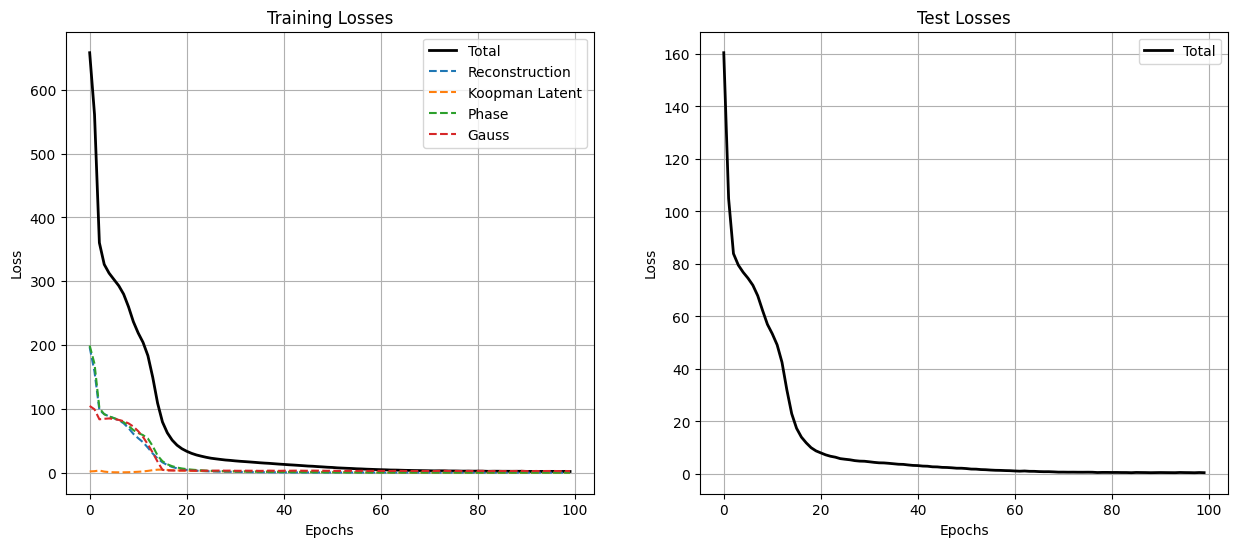

In [20]:
# Print best losses
best_train_loss = min(train_losses["total"])
avg_best_train_loss = best_train_loss / n_batch

best_test_loss = min(test_losses["total"])
avg_best_test_loss = best_test_loss / n_batch

print(
    f"Best Train Loss: {best_train_loss:.4f}, Avg per Batch: {avg_best_train_loss:.4f}"
)
print(f"Best Test Loss: {best_test_loss:.4f}, Avg per Batch: {avg_best_test_loss:.4f}")

epochs_range = range(n_epoch)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Train Losses
ax1.plot(epochs_range, train_losses["total"], label="Total", linewidth=2, color="black")
ax1.plot(epochs_range, train_losses["l1"], label="Reconstruction", linestyle="--")
ax1.plot(epochs_range, train_losses["l2"], label="Koopman Latent", linestyle="--")
ax1.plot(epochs_range, train_losses["l3"], label="Phase", linestyle="--")
ax1.plot(epochs_range, train_losses["l4"], label="Gauss", linestyle="--")
ax1.set_title("Training Losses")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, test_losses["total"], label="Total", linewidth=2, color="black")
ax2.set_title("Test Losses")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.show()

>**${\large\textbf{\green{Answer:}}}$ Regarding the loss dynamics, at the beginning of the training, the total loss is dominated by the reconstruction and phase losses, which is expected since the autoencoder and Koopman operator start from random weights. During the first $\sim20$ epochs, there is a rapid drop in the reconstruction and phase losses as the model quickly learns to build latent embeddings that capture the main features of the input data. The "Gaussian" loss also decreases steadily, indicating that the latent variables are not drifting or collapsing. After this initial phase, the training enters a slower and more stable regime where all losses decrease more gradually. The test loss follows a similar trend to the training loss, indicating that the model is generalizing well. The Koopman latent loss behaves differently, showing a slight decrease at the beginning then increasing before stabilizing. This could be because, as the encoder improves, the latent representations become more complex and meaningful. Eventually, the model reaches a compromise where the latent representations are informative enough while still being stable under the Koopman operator.**
>
>**The total loss function was designed to balance the contributions of the reconstruction loss, Koopman latent loss, phase loss, and "Gaussian" loss. By setting our weights ($\alpha, \beta,\gamma,\delta $) as they are, we first prioritized the Koopman latent loss ($\beta=5$) to ensure that the latent representations evolve linearly under the Koopman operator, which is crucial for capturing the system's dynamics. Then, the phase loss ($\gamma=2$) was given moderate importance to ensure accurate predictions in the original phase space, while the reconstruction loss ($\alpha=1$) was weighted lower to allow some flexibility in the autoencoder's ability while ensuring that it did not discard essential information about the original state. Finally, the "Gaussian" loss ($\delta=0.5$) was used as a small regularization term to prevent the latent space from collapsing.**
>
>**Also, freezing the autoencoder parameters during the computation of the Koopman latent loss ensures that the encoder does not overfit to make this loss small at the expense of everything else and forces the Koopman operator itself to learn meaningful linear dynamics.**

#### Verification

**Question 4.** : We want to ensure the Koopman operator is stable. This can be verified by checking whether its spectral radius $\rho(\mathbf{K})\le 1$. Plot the eigenvalues of the Koopman operator in order to verify the bound on its spectral radius. You can use the [`numpy.linalg.eig`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) function to retrieve the eigenvalues of a matrix.

Spectral radius: 0.9970136880874634


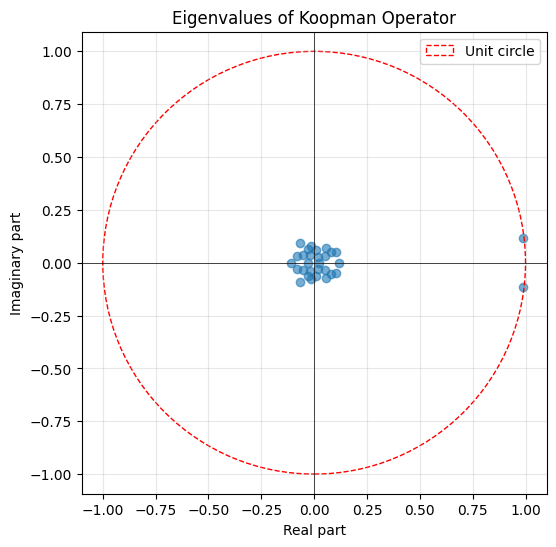

In [21]:
# Check the spectrum initialisation
koopman_matrix = koopman_operator.weight.cpu().detach().numpy()
eigenvalues = np.linalg.eig(koopman_matrix)[0]
spectral_radius = np.max(np.abs(eigenvalues))
print(f"Spectral radius: {spectral_radius.item()}")

# Plot eigenvalues in the complex plane
plt.figure(figsize=(6, 6))
plt.scatter(eigenvalues.real, eigenvalues.imag, alpha=0.6)
circle = plt.Circle(
    (0, 0), 1, color="r", fill=False, linestyle="--", label="Unit circle"
)
plt.gca().add_patch(circle)
plt.axhline(y=0, color="k", linestyle="-", linewidth=0.5)
plt.axvline(x=0, color="k", linestyle="-", linewidth=0.5)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Eigenvalues of Koopman Operator")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

results["koopman_operator_eigenvalues"] = eigenvalues

In [22]:
n_grid = 30
x1_min, x1_max = -2, 2
x2_min, x2_max = -2, 2

array_x1 = np.linspace(x1_min, x1_max, n_grid, dtype=np.float32)
array_x2 = np.linspace(x2_min, x2_max, n_grid, dtype=np.float32)
matrix_grid_x1, matrix_grid_x2 = np.meshgrid(array_x1, array_x2)

array3d_dynamics = np.zeros((n_grid, n_grid, 2), dtype=np.float32)

for i in range(n_grid):
    for j in range(n_grid):
        x1 = matrix_grid_x1[i, j]
        x2 = matrix_grid_x2[i, j]
        array3d_dynamics[i, j, :] = duffing(np.array([x1, x2]))

# Set evaluation mode
autoencoder.eval()
koopman_operator.eval()

array3d_dynamics_pred = np.zeros((n_grid, n_grid, 2), dtype=np.float32)

for i in range(n_grid):
    for j in range(n_grid):
        x1 = matrix_grid_x1[i, j]
        x2 = matrix_grid_x2[i, j]
        tensor2d_x = torch.tensor([[x1, x2]], dtype=torch.float32).to(device)
        tensor2d_observable = autoencoder.encoder(tensor2d_x)
        tensor2d_koopman_observable_next = koopman_operator(tensor2d_observable)
        tensor2d_predict_x_next = autoencoder.decoder(tensor2d_koopman_observable_next)
        array_x_next = tensor2d_predict_x_next.cpu().detach().numpy().ravel()

        # Here we compute a discretised version of the derivative thanks to the Koopman operator
        # and the learned encoder/decoder

        # (x_{k+1} - x_k) / \delta_t = f(x_k) is approximated by (f is duffing here)
        # (Decod(K(Encod(x_k))) - x_k) / \delta_t

        delta_time = t_max / n_iter
        array3d_dynamics_pred[i, j, :] = (array_x_next - [x1, x2]) / delta_time


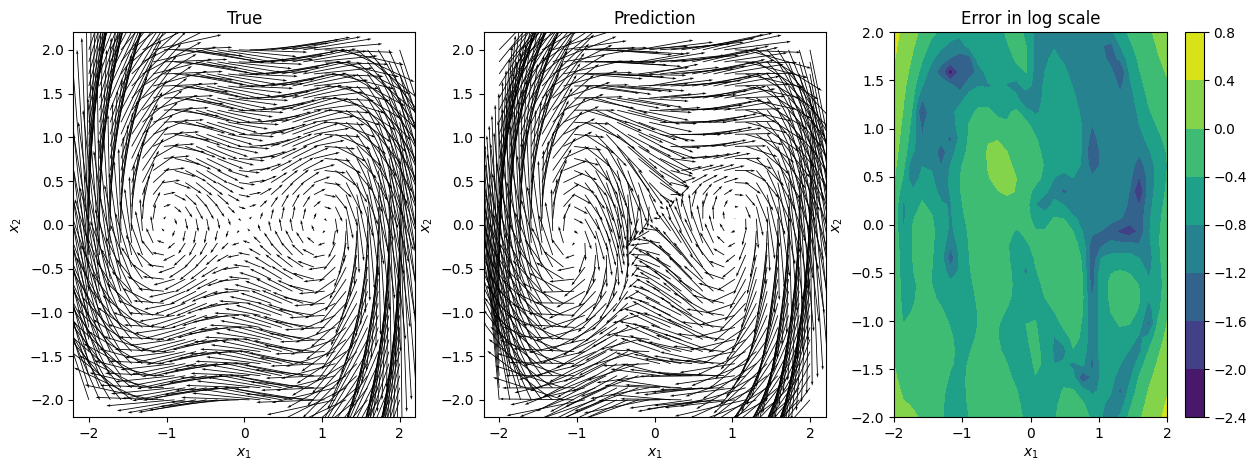

In [23]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131)
ax.quiver(
    matrix_grid_x1,
    matrix_grid_x2,
    array3d_dynamics[:, :, 0],
    array3d_dynamics[:, :, 1],
    scale=10,
)
ax.set_title("True")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax = fig.add_subplot(132)
ax.quiver(
    matrix_grid_x1,
    matrix_grid_x2,
    array3d_dynamics_pred[:, :, 0],
    array3d_dynamics_pred[:, :, 1],
    scale=10,
)

ax.set_title("Prediction")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# Compute the error
matrix_error = np.linalg.norm(array3d_dynamics - array3d_dynamics_pred, axis=2)
matrix_error_log = np.log10(matrix_error + 1e-10)

ax = fig.add_subplot(133)
cp = ax.contourf(matrix_grid_x1, matrix_grid_x2, matrix_error_log)

results["koopman_error_matrix"] = matrix_error

fig.colorbar(cp)
ax.set_title("Error in log scale")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

### Continuous in time case

Considering $x_k$ as the observation of a state at time $t = k \delta$, and $x_{k+1}$ the state at time $t+ \delta$, for $\delta \rightarrow 0$  it is also possible to define the continuous-time infinitesimal generator of the Koopman operator family as

$$
\mathcal{L} g (x_k)  = \lim_{\delta \rightarrow 0} \frac{\mathcal{K}g(x_k)- g(x_{k})}{\delta} = \frac{g \circ F (x_k) -x_k}{\delta}
$$

The pevious expression defines the Lie derivative, and for this reason $\mathcal{L}$ is known as the Lie operator. $\mathcal{L}$ describes the continuous dynamics of the observables in the Koopman space:

$$
\dot{g} (x) = \mathcal{L} g(x).
$$

The latter can be further expressed as:

$$
\dot{g} (x(t)) = \frac{dg(x)}{dt} = \nabla_x g \frac{dx}{dt} = \nabla_x g \cdot f(x) =\mathcal{L} g(x).
$$

Given $g_{\theta}$, $\varphi_{\rho}$ and $\mathbf{L}_{\phi}$ three parameterized functions, the following conditions hold:

1.   Reconstruction error
     $$
     \Vert \varphi_\rho (g_\theta(x)) - x  \Vert = 0
     $$
2.   Prediction error in Koopman space
     $$
     \Vert \mathbf{L_{\phi}} g_{\theta} ( x ) - \nabla g_{\theta} \cdot f(x)  \Vert = 0
     $$
3.   Prediction error in the phase space
     $$
     \Vert \varphi_{\rho} \left( \mathbf{L_{\phi}} g_{\theta} ( x )\right) - f(x) \Vert = 0
     $$

**Important Remark: As long as the system $f$ is known, the three errors can be computed without data belonging to trajectories.**

In [24]:
# Create a dataset for continuous Koopman
# with the same amount of points of the Discontinuous Koopman case
# But here no need to have continuous trajectories
matrix_x0 = (np.random.rand(n_initial_conditions * (n_iter - 1), 2) - 0.5) * 4
matrix_system_derivative_data = np.zeros(matrix_x0.shape)
for i in tqdm(range(matrix_x0.shape[0])):
    matrix_system_derivative_data[i, :] = duffing(matrix_x0[i, :])

100%|██████████| 299940/299940 [00:00<00:00, 1841603.03it/s]


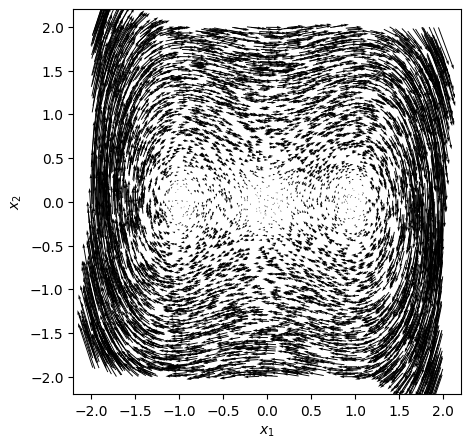

In [25]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
ax.quiver(
    matrix_x0[::50, 0],
    matrix_x0[::50, 1],
    matrix_system_derivative_data[::50, 0] * 0.2,
    matrix_system_derivative_data[::50, 1] * 0.2,
    scale=10,
)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

In [26]:
# create the models
feature_dim = 2  # dimension of the Duffing oscillator
hidden_layer = 5  # number of hidden layers in g (ENCODER) and \varphi (DECODER)
output_dim = 30  # dimension in Koopman space
batch_size = 2000  # data per batch

In [27]:
(
    matrix_x_data_train,
    matrix_x_data_test,
    matrix_x_next_data_train,
    matrix_x_next_data_test,
) = train_test_split(matrix_x0, matrix_system_derivative_data, test_size=0.2)

# Cast type to float32
matrix_x_data_train = matrix_x_data_train.astype(np.float32)
matrix_x_data_test = matrix_x_data_test.astype(np.float32)
matrix_x_next_data_train = matrix_x_next_data_train.astype(np.float32)
matrix_x_next_data_test = matrix_x_next_data_test.astype(np.float32)

print(
    matrix_x_data_train.shape,
    matrix_x_data_test.shape,
    matrix_x_next_data_train.shape,
    matrix_x_next_data_test.shape,
)

torch_dataset_train = TensorDataset(
    torch.from_numpy(matrix_x_data_train), torch.from_numpy(matrix_x_next_data_train)
)
torch_dataset_test = TensorDataset(
    torch.from_numpy(matrix_x_data_test), torch.from_numpy(matrix_x_next_data_test)
)

train_dataloader = DataLoader(torch_dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(torch_dataset_test, batch_size=batch_size, shuffle=True)

(239952, 2) (59988, 2) (239952, 2) (59988, 2)


The Lie operator must be defined such that it will be always stable by construction.
To do that, we consider a matrix of parameters $\Psi \in \mathbb{R}^{m \times m}$ and a vector of parameters $\Gamma \in \mathbb{R}^m$. The resulting Lie operator will be of the form:

$$
\mathbf{L} = (\Psi - \Psi^T) - \text{diag}(\vert \Gamma \vert)
$$

with eigenvalues whose real part $\Re(\lambda) \leq 0$ .
See https://math.stackexchange.com/questions/952233/eigenvalues-of-the-sum-of-a-diagonal-matrix-and-a-skew-symmetric-matrix for the mathematical proof (identify the matrix). Moreover if $\lambda \in \mathbb{C}$ is an eigenvalue of $\mathbf{L}$, it turns out that its real part $\Re(\lambda) \propto \Vert \Gamma \Vert$, i.e. it only depends on $\Gamma$.

Remark: $- \text{diag}(\vert \Gamma \vert)$ is always a diagonal matrix with non-positive elements.


**Question 5.** : As you did for the discrete case, you now have to implement the `LieModule` module. It should have the form indicated above to guarantee $\Re(\lambda) \leq 0$. Check that the initialization fulfills this property.

In [28]:
class LieModule(nn.Module):
    def __init__(self, lie_operator_dim: int):
        super().__init__()
        self.lie_operator_dim = lie_operator_dim

        self.Psi = nn.Parameter(
            torch.randn(self.lie_operator_dim, self.lie_operator_dim)
        )
        self.Gamma = nn.Parameter(torch.randn(self.lie_operator_dim))
        self.weight = self.create_matrix_weight()

    def create_matrix_weight(self):
        skew_Psi = self.Psi - self.Psi.T
        diag = torch.diag(torch.abs(self.Gamma))

        return nn.Parameter(skew_Psi - diag)

    def forward(self, tensor2d_x: torch.Tensor):
        if tensor2d_x.shape[1] != self.lie_operator_dim:
            sys.exit(
                f"Wrong Input Features. Please use tensor"
                f" with {self.lie_operator_dim} Input Features"
            )

        return torch.matmul(tensor2d_x, self.weight.T)

In [29]:
autoencoder = Autoencoder(feature_dim, hidden_layer, output_dim).to(device)
lie_operator = LieModule(output_dim).to(device)
print(autoencoder)
results["lie_operator_weight"] = lie_operator.weight.cpu().detach().numpy()
results["lie_operator_forward"] = (
    lie_operator(torch.ones(1, output_dim).to(device)).cpu().detach().numpy()
)

Autoencoder(
  (encoder): Encoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=2, out_features=7, bias=True)
      (1): Linear(in_features=7, out_features=13, bias=True)
      (2): Linear(in_features=13, out_features=18, bias=True)
      (3): Linear(in_features=18, out_features=24, bias=True)
      (4): Linear(in_features=24, out_features=30, bias=True)
    )
  )
  (decoder): Decoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=30, out_features=24, bias=True)
      (1): Linear(in_features=24, out_features=18, bias=True)
      (2): Linear(in_features=18, out_features=13, bias=True)
      (3): Linear(in_features=13, out_features=7, bias=True)
      (4): Linear(in_features=7, out_features=2, bias=True)
    )
  )
)


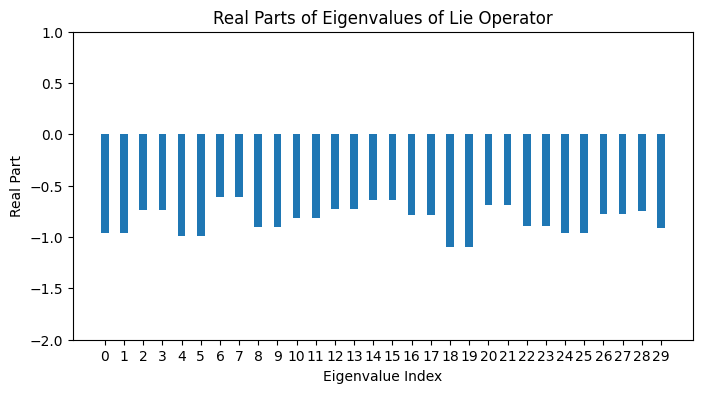

All eigenvalues have negative real parts: True


In [30]:
# Compute the Lie matrix
lie_matrix = lie_operator.weight.cpu().detach().numpy()

# Compute the eigenvalues and their real parts
eigenvalues = np.linalg.eig(lie_matrix)[0]
real_parts = np.real(eigenvalues)

# Plot
x = np.arange(len(eigenvalues))
plt.figure(figsize=(8, 4))
plt.bar(x, real_parts, width=0.4)
plt.ylim(-2, 1)
plt.xticks(x)
plt.xlabel("Eigenvalue Index")
plt.ylabel("Real Part")
plt.title("Real Parts of Eigenvalues of Lie Operator")
plt.show()

print(f"All eigenvalues have negative real parts: {np.all(real_parts < 1e-6)}")


Some tricks are needed to train. If the autoencoder and the Lie model are learned at the same speed, the training turns out to be highly unstable since the three loss functions have moving targets. For this reason, the Lie learning rate has been chosen smaller than the autoencoder one.

In [31]:
learning_rate_autoencoder = 0.0001
learning_rate_lie = 0.00001

optimiser_autoencoder = torch.optim.Adam(
    autoencoder.parameters(), lr=learning_rate_autoencoder, weight_decay=1e-3
)
optimiser_lie = torch.optim.Adam(
    lie_operator.parameters(), lr=learning_rate_lie, weight_decay=1e-3
)

A further loss is considered to stabilize the learning stage. The state $x$ belongs to a compact set, since it is the solution of a dissipative dynamical system. This is not true for $g(x)$ (we need to choose appropriate activation functions to have appropriate Liptchitz guarantees). To avoid discrepancies in magnitudes of $g_i(x)$, a regularization loss is added:

$$
\mu = \frac{1}{m} \sum_m g_i(x) = 0  \quad \text{and} \quad  \sigma = \left( \frac{1}{m}\sum_m(g_i(x)-\mu)^2 \right)^{1/2} = 1
$$

inspired by VAE.

For the training to be smooth, the encoder parameters are not affected by the **prediction loss in phase space**. This is based on an empirical observation and is motivated by the fact that the encoder appears in the three losses and plays a competitive role against the decoder and the Lie model. This should not affect the results since the encoder remains coupled with the decoder in the **reconstruction loss** and with the Lie operator in the **prediction loss in Koopman space**.

**Question 6.** : Implement the loss function similarly to what you did for the **Question 2.** Note that here you should use the dynamics $f$ and its values for a set of points belonging to the domain $\left[ -2, 2 \right]^2$ while no data from proper **trajectories** are needed.

In [32]:
# Implement the loss function here
# See the training process below to identify the different components of the loss
def loss(
    tensor2d_x: torch.Tensor,
    tensor2d_x_next: torch.Tensor,
    tensor2d_decoded_x: torch.Tensor,
    tensor2d_observable: torch.Tensor,
    tensor2d_lie_observable: torch.Tensor,
    tensor2d_predict_x: torch.Tensor,
    tensor2d_jvp: torch.Tensor,
):
    criterion = nn.MSELoss()

    # Compute the losses
    loss_reconstruction = criterion(tensor2d_decoded_x, tensor2d_x)

    for param in autoencoder.parameters():
        param.requires_grad = False

    loss_lie_latent = criterion(tensor2d_lie_observable, tensor2d_jvp)
    loss_phase = criterion(tensor2d_predict_x, tensor2d_x_next)

    for param in autoencoder.parameters():
        param.requires_grad = True

    loss_gauss = torch.abs(torch.mean(tensor2d_observable)) + torch.abs(
        torch.std(tensor2d_observable) - 1
    )

    # Coefficients for the losses
    alpha = 1.0
    beta = 5.0
    gamma = 2.0
    delta = 0.5

    total_loss = (
        alpha * loss_reconstruction
        + beta * loss_lie_latent
        + gamma * loss_phase
        + delta * loss_gauss
    )

    return total_loss

**Since trajectories are not needed**, random states can be sampled from the system manifold $x_1 \in [-2, 2]$, $x_2 \in [-2, 2]$.

In [33]:
n_batch = len(train_dataloader)
n_epoch = 80  # To be tuned
losses_train = []
losses_test = []

for epoch in range(n_epoch):
    autoencoder.train()
    lie_operator.train()
    total_train_loss = 0

    for tensor2d_batch_x, tensor2d_batch_x_next in train_dataloader:
        tensor2d_batch_x = tensor2d_batch_x.to(device)
        tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)

        optimiser_autoencoder.zero_grad()
        optimiser_lie.zero_grad()

        # dgX = lie_operator * gX
        # jvp = \nabla_x g (x) * f(x) (jvp: jacobian vector product)
        (tensor2d_observable, tensor2d_jvp) = autograd.functional.jvp(
            autoencoder.encoder,
            tensor2d_batch_x,
            tensor2d_batch_x_next,
            create_graph=True,
        )

        tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)
        tensor2d_lie_observable = lie_operator(tensor2d_observable)
        tensor2d_predict_x = autoencoder.decoder(tensor2d_lie_observable)

        tensor_loss = loss(
            tensor2d_x=tensor2d_batch_x,
            tensor2d_x_next=tensor2d_batch_x_next,
            tensor2d_decoded_x=tensor2d_decoded_x,
            tensor2d_observable=tensor2d_observable,
            tensor2d_lie_observable=tensor2d_lie_observable,
            tensor2d_predict_x=tensor2d_predict_x,
            tensor2d_jvp=tensor2d_jvp,
        )

        tensor_loss.backward()
        optimiser_autoencoder.step()
        optimiser_lie.step()

        total_train_loss += tensor_loss.item()

    autoencoder.eval()
    lie_operator.eval()
    with torch.no_grad():
        total_test_loss = 0
        for tensor2d_batch_x, tensor2d_batch_x_next in test_dataloader:
            tensor2d_batch_x = tensor2d_batch_x.to(device)
            tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)

            (tensor2d_observable, tensor2d_jvp) = autograd.functional.jvp(
                autoencoder.encoder,
                tensor2d_batch_x,
                tensor2d_batch_x_next,
                create_graph=True,
            )
            tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)

            tensor2d_lie_observable = lie_operator(tensor2d_observable)
            tensor2d_predict_x = autoencoder.decoder(tensor2d_lie_observable)

            tensor_loss = loss(
                tensor2d_x=tensor2d_batch_x,
                tensor2d_x_next=tensor2d_batch_x_next,
                tensor2d_decoded_x=tensor2d_decoded_x,
                tensor2d_observable=tensor2d_observable,
                tensor2d_lie_observable=tensor2d_lie_observable,
                tensor2d_predict_x=tensor2d_predict_x,
                tensor2d_jvp=tensor2d_jvp,
            )
            total_test_loss += tensor_loss.item()

        losses_train.append(total_train_loss / n_batch)
        losses_test.append(total_test_loss / len(test_dataloader))
        print(
            "epoch : ",
            epoch,
            "test loss : ",
            total_test_loss / len(test_dataloader),
            "train loss : ",
            total_train_loss / n_batch,
        )

results["losses_lie"] = {
    "train": np.array(losses_train),
    "test": np.array(losses_test),
    "weight_lie": lie_operator.weight.cpu().detach().numpy(),
    "weight_encoder": [
        layer.weight.detach().cpu().numpy() for layer in autoencoder.encoder.list_FC
    ],
    "weight_decoder": [
        layer.weight.detach().cpu().numpy() for layer in autoencoder.decoder.list_FC
    ],
}


epoch :  0 test loss :  9.483681615193685 train loss :  12.114545226097107
epoch :  1 test loss :  7.607944027582804 train loss :  8.396744195620219
epoch :  2 test loss :  6.273394711812338 train loss :  6.927415970961253
epoch :  3 test loss :  5.532055234909057 train loss :  5.8538668592770895
epoch :  4 test loss :  5.101260821024577 train loss :  5.308087440331777
epoch :  5 test loss :  4.664755884806315 train loss :  4.8940556446711225
epoch :  6 test loss :  4.0336683591206866 train loss :  4.369538408517838
epoch :  7 test loss :  3.449862329165141 train loss :  3.717615681886673
epoch :  8 test loss :  3.11580859820048 train loss :  3.268676592906316
epoch :  9 test loss :  2.8209452867507934 train loss :  2.9712219576040906
epoch :  10 test loss :  2.335975201924642 train loss :  2.602982391913732
epoch :  11 test loss :  1.757192854086558 train loss :  2.0148355861504874
epoch :  12 test loss :  1.5229440569877624 train loss :  1.6210809528827668
epoch :  13 test loss :  1.

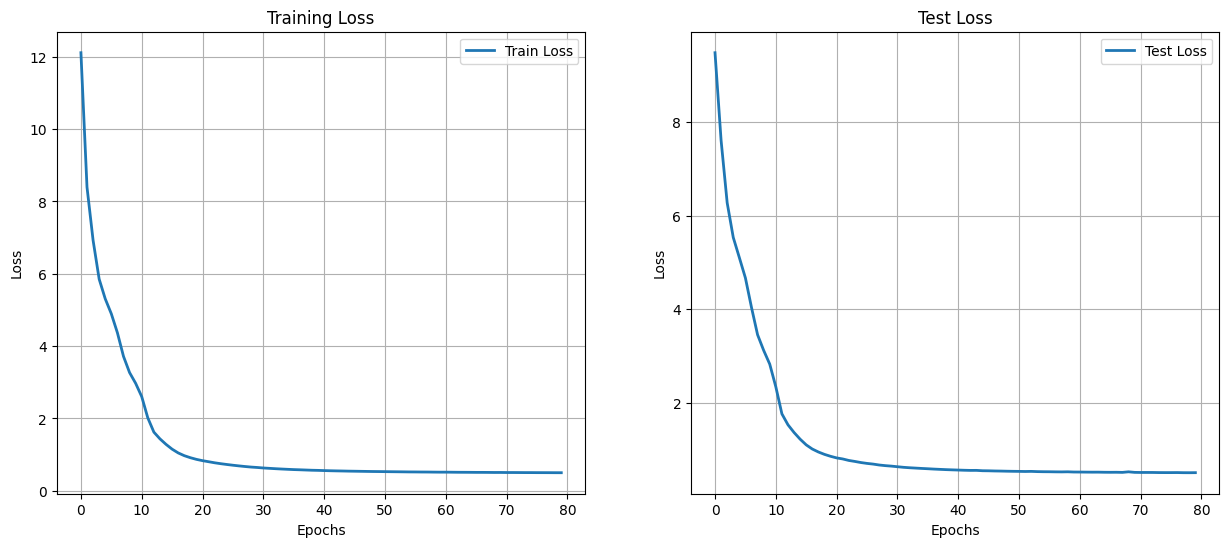

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

epochs_range = range(n_epoch)

ax1.plot(epochs_range, losses_train, label="Train Loss", linewidth=2)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.grid(True)
ax1.legend()

ax2.plot(epochs_range, losses_test, label="Test Loss", linewidth=2)
ax2.set_title("Test Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True)
ax2.legend()
plt.show()


### Verification

**Question 7.** : As in the **Question 3.** we want to ensure the Lie operator is stable. This can be verified by checking that the real part of the eigenvalues is negative. Plot the relevant eigenvalues of the Lie operator. 

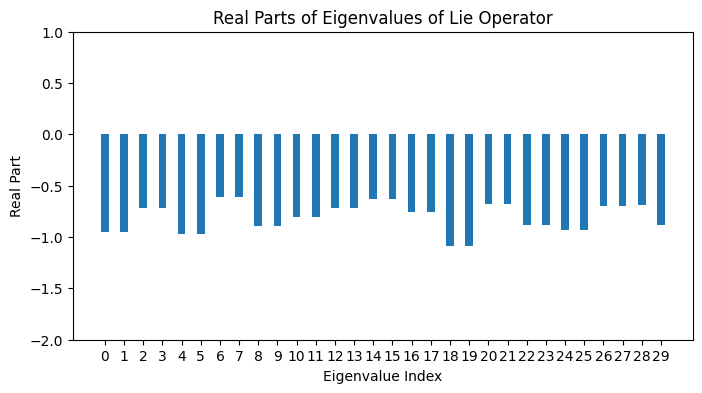

All eigenvalues have negative real parts: True


In [35]:
# Compute the Lie matrix
lie_matrix = lie_operator.weight.cpu().detach().numpy()

# Compute the eigenvalues and their real parts
eigenvalues = np.linalg.eig(lie_matrix)[0]
real_parts = np.real(eigenvalues)

# Plot
x = np.arange(len(eigenvalues))
plt.figure(figsize=(8, 4))
plt.bar(x, real_parts, width=0.4)
plt.ylim(-2, 1)
plt.xticks(x)
plt.xlabel("Eigenvalue Index")
plt.ylabel("Real Part")
plt.title("Real Parts of Eigenvalues of Lie Operator")
plt.show()

print(f"All eigenvalues have negative real parts: {np.all(real_parts < 1e-6)}")

lie_operator_eigenvalues = eigenvalues
results["lie_operator_eigenvalues"] = lie_operator_eigenvalues

In [36]:
n_grid = 30
array_x1 = np.linspace(x1_min, x1_max, n_grid, dtype=np.float32)
array_x2 = np.linspace(x2_min, x2_max, n_grid, dtype=np.float32)
matrix_grid_x1, matrix_grid_x2 = np.meshgrid(array_x1, array_x2)

array3d_dynamics = np.zeros((n_grid, n_grid, 2))

for i in range(n_grid):
    for j in range(n_grid):
        array3d_dynamics[i, j, :] = duffing(
            np.array([matrix_grid_x1[i, j], matrix_grid_x2[i, j]])
        )

autoencoder.eval()
lie_operator.eval()
array3d_dynamics_pred = np.zeros((n_grid, n_grid, 2))
for i in range(n_grid):
    for j in range(n_grid):
        x1 = matrix_grid_x1[i, j]
        x2 = matrix_grid_x2[i, j]
        tensor2d_x = torch.tensor([[x1, x2]], dtype=torch.float32).to(device)
        tensor2d_observable = autoencoder.encoder(tensor2d_x)
        tensor2d_lie_observable_next = lie_operator(tensor2d_observable)
        tensor2d_predict_x_next = autoencoder.decoder(tensor2d_lie_observable_next)
        array_x_next = tensor2d_predict_x_next.cpu().detach().numpy().ravel()

        array3d_dynamics_pred[i, j, :] = array_x_next


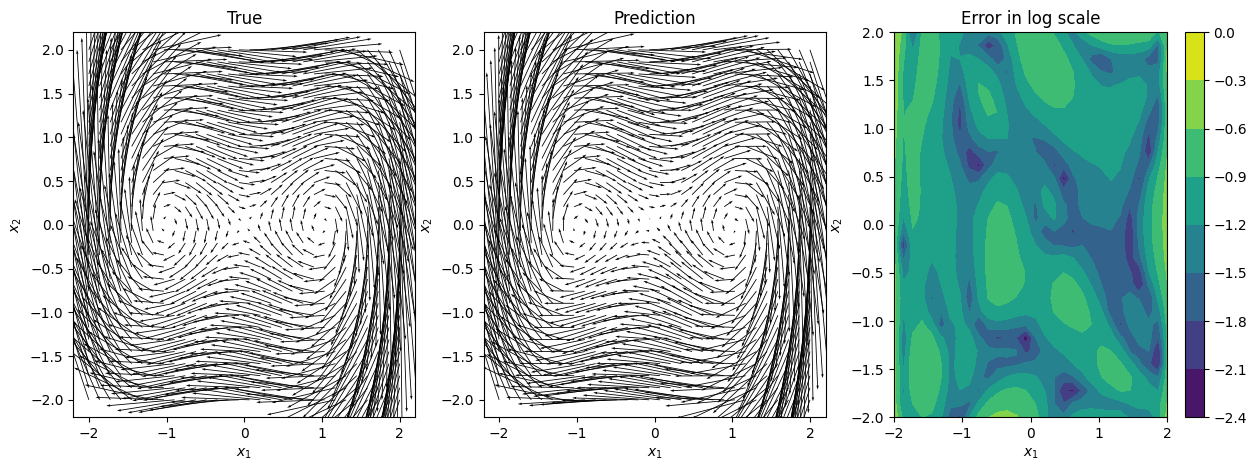

In [37]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131)
ax.quiver(
    matrix_grid_x1,
    matrix_grid_x2,
    array3d_dynamics[:, :, 0],
    array3d_dynamics[:, :, 1],
    scale=10,
)
ax.set_title("True")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax = fig.add_subplot(132)
ax.quiver(
    matrix_grid_x1,
    matrix_grid_x2,
    array3d_dynamics_pred[:, :, 0],
    array3d_dynamics_pred[:, :, 1],
    scale=10,
)
ax.set_title("Prediction")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax = fig.add_subplot(133)
matrix_error = np.linalg.norm(array3d_dynamics - array3d_dynamics_pred, axis=2)
matrix_error_log = np.log10(matrix_error + 1e-10)
results["lie_error_matrix"] = matrix_error

cp = ax.contourf(matrix_grid_x1, matrix_grid_x2, matrix_error_log)
fig.colorbar(cp)
ax.set_title("Error in log scale")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

plt.show()

**Question 8.** : Compare and comment below the two approaches (discrete vs continuous operator).

>**${\large\textbf{\green{Answer:}}}$ The discrete Koopman operator approach directly models the evolution of the system at discrete time steps. It captures the dynamics by learning a linear operator that maps the observables from one time step to the next. This make the approach conceptually simpler and well suited to data that is naturally sampled at discrete intervals. However, it may struggle with accurately capturing fast dynamics as the system is tied to the chosen time step size. In constrast, the continuous Lie operator approach models relies on learning an infinitesimal generator that describes the continuous-time evolution of the system. This allows it to capture dynamics at all time scales and therefore can be more flexible in representing complex dynamics. However, it requires access to the underlying system dynamics and correct approximation of its gradients, which may not always available in practice. In summary, the discrete Koopman operator is pften easier to learn from sampled data, while the continuous Lie operator can provide a more accurate and flexible representation at the cost of requiring more assumptions and information about the system.**
>
>**Considering the results obtained in our experiments, the continuous Lie operator approach demonstrated superior performance in capturing the dynamics of the system compared to the discrete Koopman operator method as the oscillation patterns were a little shifted in the predicted trajectories of the latter. The reason behind this observation could be because the discrete Koopman operator is limited by the fixed time step size, which can propagate errors over time, especially in systems with fast dynamics as explained earlier. On the other hand, the continuous Lie operator provides significantly better agreement with the true trajectories by accurately modeling the dynamics at all time scales.**

*-- PLEASE SUBMIT YOUR COMPLETED NOTEBOOK WITH CELL OUTPUTS --* 

*--Do not forget to submit the `.npy` file generated from the `results` dictionary--*

In [38]:
name = "Adonis_JAMAL_Jean-Vincent_MARTINI"
file_path = f"results_{name}.npy"
np.save(file_path, results)

loaded_results = np.load(file_path, allow_pickle=True).item()
print(loaded_results.keys())
assert len(loaded_results.keys()) == 11

dict_keys(['id', 'koopman_operator_weight', 'koopman_operator_forward', 'losses_koopman', 'koopman_operator_eigenvalues', 'koopman_error_matrix', 'lie_operator_weight', 'lie_operator_forward', 'losses_lie', 'lie_operator_eigenvalues', 'lie_error_matrix'])


In [39]:
for key in loaded_results.keys():
    if type(loaded_results[key]) is dict:
        for subkey in loaded_results[key].keys():
            print(
                f"{key} - {subkey} : {type(loaded_results[key][subkey])} with shape {loaded_results[key][subkey].shape if isinstance(loaded_results[key][subkey], np.ndarray) else 'N/A'}"
            )
    else:
        print(
            f"{key} : {type(loaded_results[key])} with shape {loaded_results[key].shape if isinstance(loaded_results[key], np.ndarray) else 'N/A'}"
        )

id : <class 'int'> with shape N/A
koopman_operator_weight : <class 'numpy.ndarray'> with shape (10, 10)
koopman_operator_forward : <class 'numpy.ndarray'> with shape (1, 10)
losses_koopman - train : <class 'numpy.ndarray'> with shape (100,)
losses_koopman - test : <class 'numpy.ndarray'> with shape (100,)
losses_koopman - weight_koopman : <class 'numpy.ndarray'> with shape (30, 30)
losses_koopman - weight_encoder : <class 'list'> with shape N/A
losses_koopman - weight_decoder : <class 'list'> with shape N/A
koopman_operator_eigenvalues : <class 'numpy.ndarray'> with shape (30,)
koopman_error_matrix : <class 'numpy.ndarray'> with shape (30, 30)
lie_operator_weight : <class 'numpy.ndarray'> with shape (30, 30)
lie_operator_forward : <class 'numpy.ndarray'> with shape (1, 30)
losses_lie - train : <class 'numpy.ndarray'> with shape (80,)
losses_lie - test : <class 'numpy.ndarray'> with shape (80,)
losses_lie - weight_lie : <class 'numpy.ndarray'> with shape (30, 30)
losses_lie - weight_enc